# LLM-Judge-Bench: Meta-Evaluation Framework Demo

This notebook demonstrates the full LLM-Judge-Bench framework:
1. **Judge Architectures** — Pointwise, Pairwise, and Reference-based evaluation
2. **Configurable Rubrics** — YAML-based evaluation criteria
3. **Inter-Rater Reliability** — Cohen's Kappa, Krippendorff's Alpha, correlations
4. **Meta-Audit Pipeline** — Evaluating how well judges align with humans
5. **Sampling Strategies** — Efficient audit sample selection

**Note:** To run with live Gemini API calls, set `GOOGLE_API_KEY`. The demo also works with simulated judge scores to show the full analytics pipeline.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Environment ready.')

Matplotlib is building the font cache; this may take a moment.


Environment ready.


## 1. Load Dataset & Rubrics

In [2]:
from llm_judge_bench.rubrics.rubric import Rubric, RubricRegistry

# Load built-in rubrics
registry = RubricRegistry.with_defaults()
print('Available rubrics:', registry.list_rubrics())

rubric = registry.get('helpfulness')
print(f'\nRubric: {rubric.name}')
print(f'Scale: {rubric.scale_min}-{rubric.scale_max}')
print(f'Dimensions:')
for dim, desc, w in zip(rubric.dimensions, rubric.dimension_descriptions, 
                         [rubric.dimension_weights.get(d, 1.0) for d in rubric.dimensions]):
    print(f'  - {dim} (weight={w}): {desc[:80]}...')

Available rubrics: ['factual_accuracy', 'safety', 'helpfulness']

Rubric: helpfulness
Scale: 1-10
Dimensions:
  - Accuracy (weight=2.0): Factual correctness of the response. Are claims accurate and verifiable? Are the...
  - Completeness (weight=1.5): Does the response fully address all aspects of the question? Are important nuanc...
  - Clarity (weight=1.0): Is the response well-organized and easy to understand? Is the language precise a...
  - Relevance (weight=1.0): Does the response stay focused on the user's actual question? Is there unnecessa...
  - Depth (weight=1.0): Does the response provide sufficient detail and insight? Does it go beyond surfa...


In [3]:
# Load MT-Bench sample dataset
with open('../data/mt_bench_sample.json') as f:
    data = json.load(f)

df_data = pd.DataFrame(data)
print(f'Dataset: {len(data)} items')
print(f'Categories: {df_data["category"].value_counts().to_dict()}')
print(f'Human score distribution: mean={df_data["human_score"].mean():.1f}, '
      f'std={df_data["human_score"].std():.1f}')

Dataset: 20 items
Categories: {'reasoning': 7, 'writing': 5, 'coding': 5, 'math': 3}
Human score distribution: mean=7.5, std=2.8


## 2. Run LLM Judge (or Simulate)

If `GOOGLE_API_KEY` is set, this runs the actual Gemini judge. Otherwise, we simulate realistic judge scores to demonstrate the full analytics pipeline.

In [10]:
import os

USE_LIVE_API = bool(os.environ.get('GOOGLE_API_KEY'))

if USE_LIVE_API:
    from llm_judge_bench.providers.gemini import GeminiProvider
    from llm_judge_bench.pipeline import EvaluationPipeline
    
    provider = GeminiProvider()
    pipeline = EvaluationPipeline(provider, rubric, judge_type='pointwise')
    results = pipeline.run(data, max_items=20)
    judge_scores = [r.score for r in results]
    dimension_scores = [r.dimension_scores for r in results]
    print(f'Live evaluation complete: {len(results)} items judged')
else:
    # Simulate realistic judge scores: correlated with human scores + noise
    np.random.seed(42)
    human_scores = [item['human_score'] for item in data]
    noise = np.random.normal(0, 1.2, len(human_scores))
    # Add slight positive bias (judges tend to be lenient)
    bias = 0.4
    judge_scores = np.clip(
        np.array(human_scores, dtype=float) + noise + bias, 1, 10
    ).round().tolist()
    
    # Simulate dimension scores
    dimension_scores = []
    for hs in human_scores:
        dims = {}
        for dim in rubric.dimensions:
            dims[dim] = float(np.clip(hs + np.random.normal(0, 1.5), 1, 10).round())
        dimension_scores.append(dims)
    
    print(f'Simulated {len(judge_scores)} judge scores (set GOOGLE_API_KEY for live evaluation)')
    print(f'Judge scores: {judge_scores}')

Running pointwise judge: 100%|██████████| 20/20 [02:04<00:00,  6.23s/it]

Live evaluation complete: 20 items judged


## 3. Inter-Rater Agreement Analysis

In [11]:
from llm_judge_bench.metrics.agreement import AgreementMetrics

human_scores = [item['human_score'] for item in data]
report = AgreementMetrics.compute(judge_scores, human_scores)
print(report.summary())

Agreement Report (n=20)
Cohen's Kappa (exact):      +0.228
Weighted Kappa (ordinal):    +0.835
Krippendorff's Alpha:        +0.925
Pearson r:                   +0.955 (p=1.0000)
Spearman ρ:                  +0.744 (p=1.0000)
Exact accuracy:              40.0%
Near accuracy (±1):          70.0%
MAE:                         0.800
RMSE:                        1.068
Bias (judge - human):        +0.700


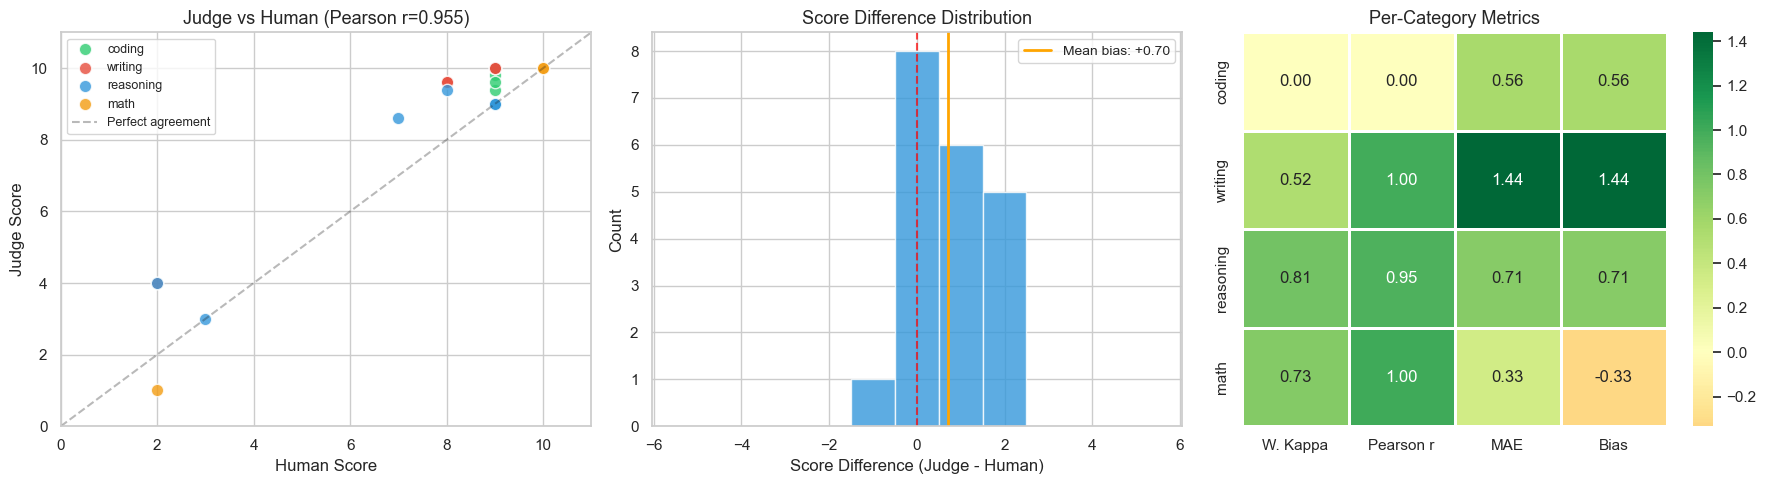

Saved: outputs/agreement_analysis.png


In [12]:
# Visualization: Judge vs Human Score Scatter Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Scatter with regression line
ax = axes[0]
categories = [item['category'] for item in data]
cat_colors = {'writing': '#e74c3c', 'reasoning': '#3498db', 
              'coding': '#2ecc71', 'math': '#f39c12'}
for cat in set(categories):
    mask = [c == cat for c in categories]
    h = [human_scores[i] for i in range(len(mask)) if mask[i]]
    j = [judge_scores[i] for i in range(len(mask)) if mask[i]]
    ax.scatter(h, j, c=cat_colors.get(cat, '#95a5a6'), label=cat, s=80, alpha=0.8, edgecolors='white')

# Perfect agreement line
ax.plot([0, 11], [0, 11], 'k--', alpha=0.3, label='Perfect agreement')
ax.set_xlabel('Human Score', fontsize=12)
ax.set_ylabel('Judge Score', fontsize=12)
ax.set_title(f'Judge vs Human (Pearson r={report.pearson_r:.3f})', fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(0, 11)
ax.set_ylim(0, 11)

# Plot 2: Score difference distribution
ax = axes[1]
diffs = [judge_scores[i] - human_scores[i] for i in range(len(judge_scores))]
ax.hist(diffs, bins=np.arange(-5.5, 6.5, 1), color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=np.mean(diffs), color='orange', linestyle='-', linewidth=2, label=f'Mean bias: {np.mean(diffs):+.2f}')
ax.set_xlabel('Score Difference (Judge - Human)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Score Difference Distribution', fontsize=13)
ax.legend(fontsize=10)

# Plot 3: Per-category agreement heatmap
ax = axes[2]
cat_metrics = {}
for cat in set(categories):
    mask = [c == cat for c in categories]
    h = [human_scores[i] for i in range(len(mask)) if mask[i]]
    j = [judge_scores[i] for i in range(len(mask)) if mask[i]]
    if len(h) >= 3:
        cat_report = AgreementMetrics.compute(j, h)
        cat_metrics[cat] = {
            'W. Kappa': cat_report.weighted_kappa,
            'Pearson r': cat_report.pearson_r,
            'MAE': cat_report.mae,
            'Bias': cat_report.bias,
        }

cat_df = pd.DataFrame(cat_metrics).T
sns.heatmap(cat_df, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax,
            linewidths=1, linecolor='white')
ax.set_title('Per-Category Metrics', fontsize=13)

plt.tight_layout()
plt.savefig('../outputs/agreement_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/agreement_analysis.png')

## 4. Meta-Audit Report

In [13]:
from llm_judge_bench.meta_audit.evaluator import MetaAuditor

auditor = MetaAuditor(tolerance=1)
meta_report = auditor.audit(
    judge_scores=judge_scores,
    human_scores=human_scores,
    categories=categories,
)

print(meta_report.summary())

META-AUDIT REPORT

--- Overall Agreement ---
Agreement Report (n=20)
Cohen's Kappa (exact):      +0.228
Weighted Kappa (ordinal):    +0.835
Krippendorff's Alpha:        +0.925
Pearson r:                   +0.955 (p=1.0000)
Spearman ρ:                  +0.744 (p=1.0000)
Exact accuracy:              40.0%
Near accuracy (±1):          70.0%
MAE:                         0.800
RMSE:                        1.068
Bias (judge - human):        +0.700

--- Per-Category Weighted Kappa ---
  coding              : κ_w=+0.000  (n=5, bias=+0.56)
  math                : κ_w=+0.727  (n=3, bias=-0.33)
  reasoning           : κ_w=+0.809  (n=7, bias=+0.71)
  writing             : κ_w=+0.522  (n=5, bias=+1.44)

--- Bias Analysis ---
  mean_bias: 0.7
  median_bias: 0.7000000000000002
  std_bias: 0.806225774829855
  pct_over_scoring: 0.6
  pct_under_scoring: 0.05
  severity_skew: lenient
  judge_score_std: 2.6870057685088806
  human_score_std: 2.711088342345192
  scale_usage: similar

--- Top 10 Disagreement

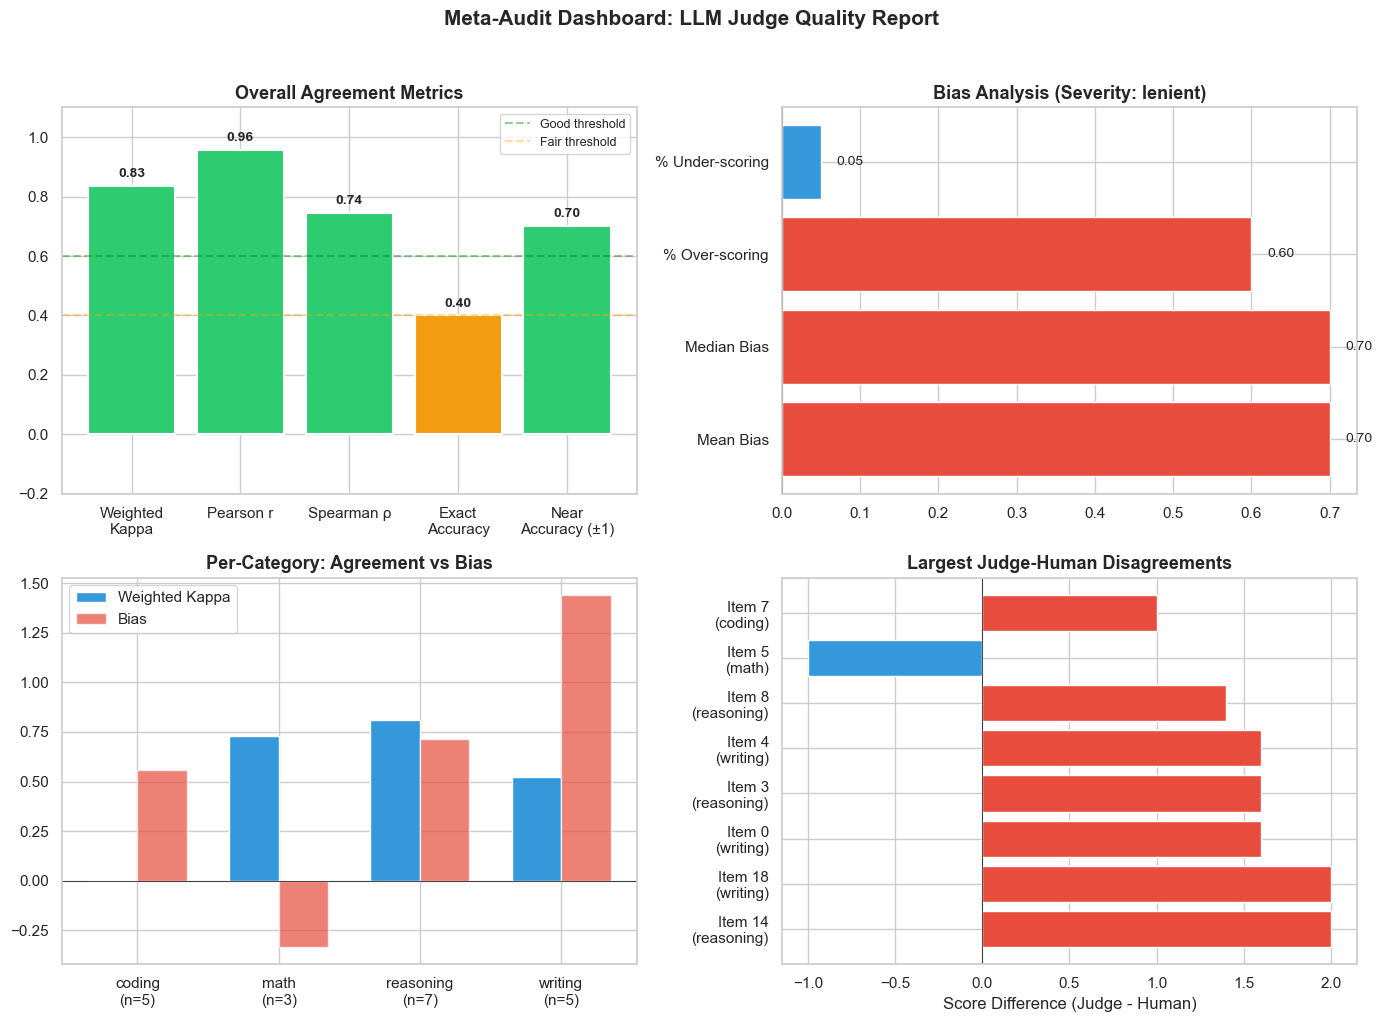

Saved: outputs/meta_audit_dashboard.png


In [14]:
# Visualization: Meta-Audit Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Overall metrics radar-style bar chart
ax = axes[0, 0]
metrics_dict = meta_report.overall_agreement.to_dict()
display_metrics = ['weighted_kappa', 'pearson_r', 'spearman_rho', 'exact_accuracy', 'near_accuracy']
display_labels = ['Weighted\nKappa', 'Pearson r', 'Spearman ρ', 'Exact\nAccuracy', 'Near\nAccuracy (±1)']
values = [metrics_dict[m] for m in display_metrics]
colors = ['#2ecc71' if v > 0.6 else '#f39c12' if v > 0.3 else '#e74c3c' for v in values]
bars = ax.bar(display_labels, values, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylim(-0.2, 1.1)
ax.axhline(y=0.6, color='green', linestyle='--', alpha=0.4, label='Good threshold')
ax.axhline(y=0.4, color='orange', linestyle='--', alpha=0.4, label='Fair threshold')
ax.set_title('Overall Agreement Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Bias analysis
ax = axes[0, 1]
bias_data = meta_report.bias_analysis
bias_metrics = ['mean_bias', 'median_bias', 'pct_over_scoring', 'pct_under_scoring']
bias_labels = ['Mean Bias', 'Median Bias', '% Over-scoring', '% Under-scoring']
bias_values = [bias_data.get(m, 0) for m in bias_metrics]
bias_colors = ['#e74c3c' if abs(v) > 0.5 else '#3498db' for v in bias_values]
bars = ax.barh(bias_labels, bias_values, color=bias_colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title(f'Bias Analysis (Severity: {bias_data.get("severity_skew", "N/A")})', 
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, bias_values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2.,
            f'{val:.2f}', ha='left', va='center', fontsize=10)

# Plot 3: Category-level weighted kappa comparison
ax = axes[1, 0]
if meta_report.category_agreement:
    cats = list(meta_report.category_agreement.keys())
    kappas = [meta_report.category_agreement[c].weighted_kappa for c in cats]
    biases = [meta_report.category_agreement[c].bias for c in cats]
    n_samples = [meta_report.category_agreement[c].n_samples for c in cats]
    
    x = np.arange(len(cats))
    width = 0.35
    bars1 = ax.bar(x - width/2, kappas, width, label='Weighted Kappa', color='#3498db')
    bars2 = ax.bar(x + width/2, biases, width, label='Bias', color='#e74c3c', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{c}\n(n={n})' for c, n in zip(cats, n_samples)])
    ax.legend()
    ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Per-Category: Agreement vs Bias', fontsize=13, fontweight='bold')

# Plot 4: Top disagreements
ax = axes[1, 1]
if meta_report.failure_analysis:
    top_fails = meta_report.failure_analysis[:8]
    indices = [f"Item {f['index']}\n({f['category']})" for f in top_fails]
    diffs = [f['judge_score'] - f['human_score'] for f in top_fails]
    colors = ['#e74c3c' if d > 0 else '#3498db' for d in diffs]
    ax.barh(indices, diffs, color=colors, edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Score Difference (Judge - Human)')
ax.set_title('Largest Judge-Human Disagreements', fontsize=13, fontweight='bold')

plt.suptitle('Meta-Audit Dashboard: LLM Judge Quality Report', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/meta_audit_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/meta_audit_dashboard.png')

## 5. Sampling Strategies for Efficient Auditing

In [15]:
from llm_judge_bench.sampling.strategies import (
    RandomSampler, StratifiedSampler, ConfidenceBasedSampler
)

# Compare sampling strategies
random_sample = RandomSampler().sample(n_total=len(data), n_select=10)
stratified_sample = StratifiedSampler().sample(categories, n_select=10, min_per_category=2)
confidence_sample = ConfidenceBasedSampler().sample(
    judge_scores, dimension_scores=dimension_scores, n_select=10
)

print('=== Sampling Strategy Comparison ===')
print(f'\nRandom: {random_sample.n_selected} items')
print(f'  Indices: {random_sample.selected_indices}')

print(f'\nStratified: {stratified_sample.n_selected} items')
print(f'  Category distribution: {stratified_sample.category_counts}')

print(f'\nConfidence-based: {confidence_sample.n_selected} items')
print(f'  Indices: {confidence_sample.selected_indices}')
print(f'  (Prioritizes items where judge was most uncertain)')

=== Sampling Strategy Comparison ===

Random: 10 items
  Indices: [0, 1, 3, 5, 8, 11, 15, 16, 17, 18]

Stratified: 8 items
  Category distribution: {'writing': 2, 'reasoning': 2, 'coding': 2, 'math': 2}

Confidence-based: 10 items
  Indices: [1, 3, 5, 6, 8, 11, 14, 17, 18, 19]
  (Prioritizes items where judge was most uncertain)


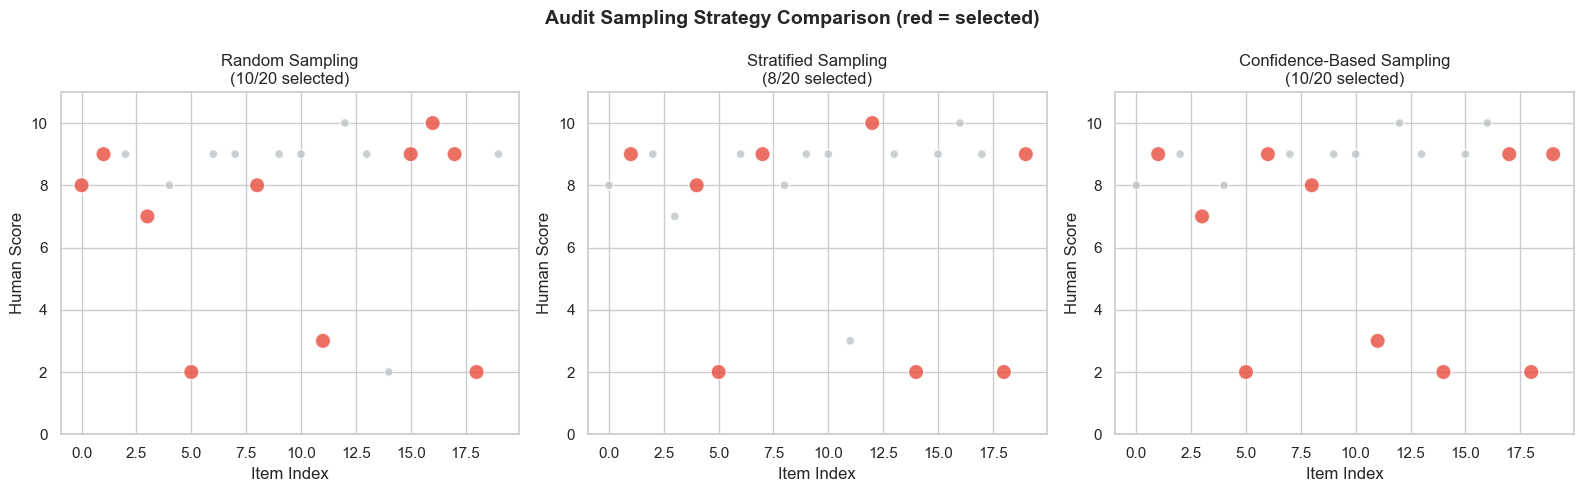

Saved: outputs/sampling_comparison.png


In [16]:
# Visualization: Sampling strategy comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, sample, name in zip(axes, 
    [random_sample, stratified_sample, confidence_sample],
    ['Random', 'Stratified', 'Confidence-Based']):
    
    # Show which items were selected
    selected_set = set(sample.selected_indices)
    colors = ['#e74c3c' if i in selected_set else '#bdc3c7' for i in range(len(data))]
    sizes = [120 if i in selected_set else 40 for i in range(len(data))]
    
    ax.scatter(range(len(data)), human_scores, c=colors, s=sizes, alpha=0.8, edgecolors='white')
    ax.set_xlabel('Item Index')
    ax.set_ylabel('Human Score')
    ax.set_title(f'{name} Sampling\n({sample.n_selected}/{sample.n_total} selected)', fontsize=12)
    ax.set_ylim(0, 11)

plt.suptitle('Audit Sampling Strategy Comparison (red = selected)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/sampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/sampling_comparison.png')

## 6. Self-Consistency Analysis

Evaluates whether the judge gives the same score when asked to evaluate the same response multiple times.

In [17]:
# Simulate repeated evaluations (in production, you'd run the judge 3+ times per item)
np.random.seed(123)
repeated_scores = {}
for i, score in enumerate(judge_scores):
    # Simulate 3 repeated evaluations with small noise
    repeated = [float(np.clip(score + np.random.normal(0, 0.8), 1, 10).round()) 
                for _ in range(3)]
    repeated_scores[f'item_{i}'] = repeated

auditor = MetaAuditor()
consistency = auditor.audit_consistency(repeated_scores)

print('=== Self-Consistency Analysis ===')
print(f'Mean Std Dev across items:  {consistency["mean_std"]:.3f}')
print(f'Max Score Range (any item): {consistency["max_range"]:.1f}')
print(f'% Perfectly Consistent:     {consistency["pct_consistent"]:.1%}')

=== Self-Consistency Analysis ===
Mean Std Dev across items:  0.534
Max Score Range (any item): 2.0
% Perfectly Consistent:     15.0%


## 7. Summary & Key Takeaways

This framework provides a complete toolkit for:
- **Building** LLM-as-a-Judge systems with multiple architectures
- **Evaluating** judge quality with rigorous statistical metrics
- **Detecting** systematic biases and failure modes
- **Optimizing** audit workflows through intelligent sampling

See the README for full API documentation and production deployment guidance.